# Part 4: DistilBERT

This is model number four in our comparison. It's a pretrained transformer that I finetuned on the same split everyone in the team used.

Parts 1 and 2 already showed the classes are easy to tell apart just from trigger words like `raped`, `fgm` and `beats`, so the scores are already really high and there isn't much room left to beat them. I picked a transformer for a different reason. It splits words into smaller pieces, so even a misspelled or unseen word still means something to it. It also comes already trained on a huge pile of text, so it isn't starting from scratch like the BiLSTM did with only 27,755 tweets.

In [1]:
!pip install -q transformers
!git clone -q https://github.com/Ebi-Tech/NLP-and-Language-Technologies.git
%cd NLP-and-Language-Technologies

/content/NLP-and-Language-Technologies


In [2]:
import re, time, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report

from src import metrics as M
from src.save_preds import save_preds

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
hardware = torch.cuda.get_device_name(0) if device == "cuda" else "CPU"
print(device, hardware)

cuda Tesla T4


## Step 1: Load the shared split

The split file only has IDs in it, so I join it with the cleaned data file to get the real text and labels. If any row ends up without text then something went wrong, so I check that too.

In [3]:
split = pd.read_csv("splits/train_val_test_split.csv")
text = pd.read_csv("data/processed/train_cleaned.csv")

df = split.merge(text[["Tweet_ID", "tweet", "label_id"]], on="Tweet_ID", how="left")

print(df["split"].value_counts().to_dict())
print("missing text:", df["tweet"].isna().sum())

{'train': 27755, 'test': 5948, 'val': 5947}
missing text: 0


## Step 2: Only light cleaning

The other models train on `tweet_clean`, which is lowercased and tidied up. I use the raw `tweet` column and only take out URLs and @handles.

The reason is that the tokenizer was pretrained on normal text, so it expects text that still looks normal. If I strip punctuation or stopwords I'd be throwing away stuff the model already knows how to use. `distilbert-base-uncased` lowercases by itself anyway, so we're still even with the other models on that.

In [4]:
def clean(t):
    t = re.sub(r"http\S+|@\w+", " ", str(t))
    return re.sub(r"\s+", " ", t).strip()

df["text"] = df["tweet"].map(clean)
df[["tweet", "text"]].head(3)

,tweet,text
0,I was raped and his commander. Nothing happene...,I was raped and his commander. Nothing happene...
1,"A few weeks ago I got drunk, caused a scene an...","A few weeks ago I got drunk, caused a scene an..."
2,True story: the man who raped me was really ni...,True story: the man who raped me was really ni...


## Step 3: Picking a sequence length

Part 1 found tweets almost never go past 68 words. But this tokenizer breaks rare words into pieces, so one word can turn into three or four tokens. That means the token count is bigger than the word count, and I should check the real numbers before picking a length, otherwise I could be cutting off half of most tweets without noticing.

In [5]:
MODEL = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL)

lens = [len(tok(t)["input_ids"]) for t in df["text"].sample(3000, random_state=42)]
print("median, 90th, 99th:", np.percentile(lens, [50, 90, 99]).round(1))
print("max:", max(lens))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

median, 90th, 99th: [56. 72. 84.]
max: 105


## Step 4: Turn the text into numbers

Each tweet becomes a fixed block of 128 token ids. The attention mask just tells the model which of those are real words and which are padding. The BiLSTM used 70 word slots, so 128 token slots covers about the same amount of text.

In [6]:
MAX_LEN = 128

def to_dataset(rows):
    enc = tok(list(rows["text"]), truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")
    return TensorDataset(enc["input_ids"], enc["attention_mask"], torch.tensor(rows["label_id"].values))

train_rows = df[df["split"] == "train"]
val_rows = df[df["split"] == "val"]
test_rows = df[df["split"] == "test"]

train_ds = to_dataset(train_rows)
val_ds = to_dataset(val_rows)
test_ds = to_dataset(test_rows)

y_val = val_rows["label_id"].values
y_test = test_rows["label_id"].values

print(len(train_ds), len(val_ds), len(test_ds))

27755 5947 5948


## Step 5: Training

This is normal fine-tuning. Load the pretrained weights, put a 5-class layer on top, and train the whole thing with a small learning rate so we don't wreck what it already knows.

`predict_proba` gives the model's confidence in all 5 classes, and `predict` just takes whichever one is highest. I need the probabilities and not only the final answer, because ROC curves are built from how confident the model was, not from what it ended up picking.

`weighted` turns class weights on or off. I left it as a switch instead of hardcoding it because that's the one experiment I run below.

In [7]:
def predict_proba(model, ds, bs=64):
    model.eval()
    out = []
    with torch.no_grad():
        for ids, mask, _ in DataLoader(ds, batch_size=bs):
            logits = model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
            out.append(torch.softmax(logits, dim=1).cpu())
    return torch.cat(out).numpy()


def predict(model, ds, bs=64):
    return predict_proba(model, ds, bs).argmax(1)


def train(weighted, epochs=3, lr=2e-5, bs=32):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=5).to(device)

    w = None
    if weighted:
        y = train_rows["label_id"].values
        w = compute_class_weight("balanced", classes=np.arange(5), y=y)
        w = torch.tensor(w, dtype=torch.float, device=device)

    loss_fn = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    loader = DataLoader(train_ds, batch_size=bs, shuffle=True)

    hist = []
    start = time.time()
    for ep in range(epochs):
        model.train()
        total = 0
        for ids, mask, y in loader:
            opt.zero_grad()
            logits = model(input_ids=ids.to(device), attention_mask=mask.to(device)).logits
            loss = loss_fn(logits, y.to(device))
            loss.backward()
            opt.step()
            total += loss.item()
        f1 = f1_score(y_val, predict(model, val_ds), average="macro", zero_division=0)
        hist.append({"epoch": ep + 1, "train_loss": total / len(loader), "val_macro_f1": f1})
        print(hist[-1])

    return model, pd.DataFrame(hist), (time.time() - start) / 60

## Step 6: Two versions

The experiment is class weights on versus off. That's the same choice Part 2 made for the BiLSTM, so the two line up.

It matters here because the rarest class only has 188 tweets in the whole dataset. Without weights the model can get a nice accuracy while basically ignoring that class. Running both means I can point at a number instead of just assuming weights help.

In [8]:
model_w, hist_w, time_w = train(weighted=True)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'epoch': 1, 'train_loss': 0.18470587132902053, 'val_macro_f1': 0.9844216108438945}
{'epoch': 2, 'train_loss': 0.005667681246915454, 'val_macro_f1': 0.995292261458555}
{'epoch': 3, 'train_loss': 0.002407952422028824, 'val_macro_f1': 0.9950276733098358}


In [9]:
model_u, hist_u, time_u = train(weighted=False)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'epoch': 1, 'train_loss': 0.07355947293647487, 'val_macro_f1': 0.9998674109199326}
{'epoch': 2, 'train_loss': 0.0028951408273193337, 'val_macro_f1': 0.9998675324311282}
{'epoch': 3, 'train_loss': 0.0019051663851058851, 'val_macro_f1': 0.9997349434219359}


## Step 7: Compare on validation

I compare the two on validation only and keep whichever did better. Test doesn't get touched until after that choice is made.

In [10]:
f1_w = hist_w["val_macro_f1"].iloc[-1]
f1_u = hist_u["val_macro_f1"].iloc[-1]
print(f"with class weights: {f1_w:.4f}")
print(f"without class weights: {f1_u:.4f}")

if f1_w >= f1_u:
    best, best_time, config = model_w, time_w, "class weights"
else:
    best, best_time, config = model_u, time_u, "no class weights"

print("kept:", config)
print(classification_report(y_val, predict(best, val_ds), target_names=M.LABEL_ORDER, zero_division=0))

with class weights: 0.9950
without class weights: 0.9997
kept: no class weights
                              precision    recall  f1-score   support

           economic_violence       1.00      1.00      1.00        33
          emotional_violence       1.00      1.00      1.00        97
harmful_traditional_practice       1.00      1.00      1.00        28
           physical_violence       1.00      1.00      1.00       892
             sexual_violence       1.00      1.00      1.00      4897

                    accuracy                           1.00      5947
                   macro avg       1.00      1.00      1.00      5947
                weighted avg       1.00      1.00      1.00      5947



## Step 8: Learning curves

Training loss shows if the model is still getting better. Validation macro F1 shows if that's real learning or just memorizing. I plot both versions on the same chart so the effect of the class weights is easy to see.

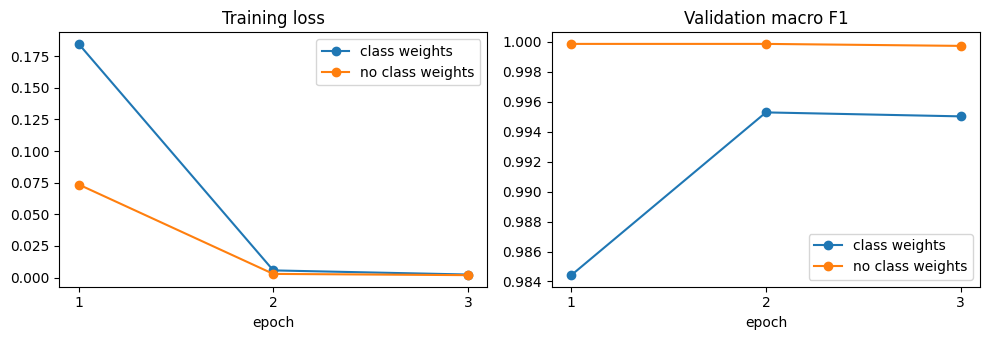

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

for h, name in [(hist_w, "class weights"), (hist_u, "no class weights")]:
    ax[0].plot(h["epoch"], h["train_loss"], marker="o", label=name)
    ax[1].plot(h["epoch"], h["val_macro_f1"], marker="o", label=name)

ax[0].set_title("Training loss")
ax[1].set_title("Validation macro F1")
for a in ax:
    a.set_xlabel("epoch")
    a.set_xticks(hist_w["epoch"])
    a.legend()

plt.tight_layout()
plt.savefig("reports/figures/distilbert_learning_curve.png", dpi=150)
plt.show()

## Step 9: Score it on test, once

One run on the test set. I use the shared `src/metrics.py` so my numbers come out in the same format as everyone else's.

Model: DistilBERT
Accuracy (leaderboard metric): 0.9993
Macro F1: 0.9954
Weighted F1: 0.9993

Per-class precision / recall / F1 / support:
  economic_violence              precision=1.000  recall=0.969  f1=0.984  support=32
  emotional_violence             precision=1.000  recall=0.990  f1=0.995  support=98
  harmful_traditional_practice   precision=1.000  recall=1.000  f1=1.000  support=28
  physical_violence              precision=0.997  recall=1.000  f1=0.998  support=892
  sexual_violence                precision=1.000  recall=1.000  f1=1.000  support=4898


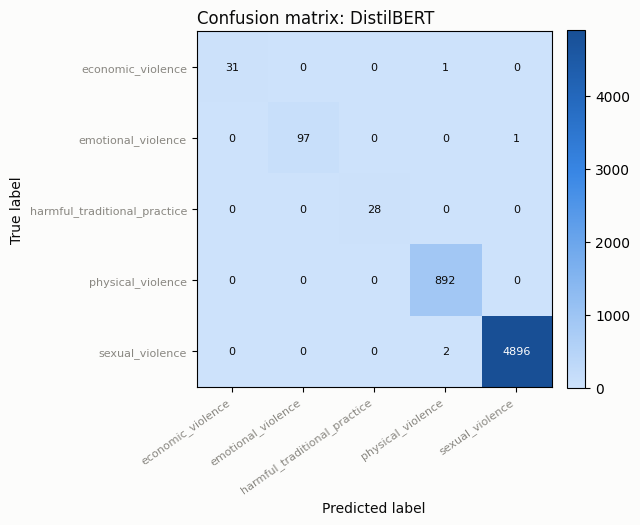

In [12]:
test_probs = predict_proba(best, test_ds)
test_preds = test_probs.argmax(1)

res = M.compute_metrics(y_test, test_preds)

print(M.format_metrics_report(res, "DistilBERT"))
M.save_metrics(res, "DistilBERT", "test")
M.plot_confusion_matrix(res["confusion_matrix"], "DistilBERT")
plt.show()

## Step 10: Save the predictions and the run details

`save_preds` writes one row per test tweet with the model's probability for all 5 classes, plus what it predicted and the right answer. It lives in `src/` so every model saves in the same format and the comparison can read them all the same way. The probabilities are there so the ROC curves can be drawn later without retraining anything.

The scores already went into `reports/results/distilbert_test.json` in Step 9, so I don't write them again. This second file only holds what that one doesn't keep: the hardware, how long training took, and which config I kept.

Nothing here overwrites a file someone else owns, and nothing gets appended to `results/model_comparison.csv`.

In [13]:
save_preds("distilbert", test_rows["Tweet_ID"], test_probs, y_test)

info = {
    "model": "DistilBERT",
    "base_model": MODEL,
    "config": config,
    "epochs": 3,
    "lr": 2e-5,
    "max_len": MAX_LEN,
    "batch_size": 32,
    "hardware": hardware,
    "training_time_min": round(best_time, 1),
}

with open("reports/results/distilbert_run_info.json", "w") as f:
    json.dump(info, f, indent=2)

pd.read_csv("results/preds_distilbert_test.csv").head()

,Tweet_ID,p_economic_violence,p_emotional_violence,p_harmful_traditional_practice,p_physical_violence,p_sexual_violence,true_id,pred_id
0,ID_XWCAARIR,0.000378,0.997229,0.000630,0.000320,0.001443,1,1
1,ID_8JUUNKDN,0.000012,0.000014,0.000039,0.000028,0.999906,4,4
2,ID_V88XYFFS,0.000029,0.000072,0.000063,0.999648,0.000188,3,3
3,ID_RB4K7AW2,0.000010,0.000012,0.000034,0.000021,0.999923,4,4
4,ID_3F7SAB23,0.000011,0.000013,0.000036,0.000025,0.999916,4,4


## Notes

This notebook only makes new files, it doesn't edit anyone else's:

- `reports/results/distilbert_test.json`
- `reports/results/distilbert_run_info.json`
- `reports/figures/distilbert_learning_curve.png`
- `reports/figures/confusion_matrix_distilbert.png`
- `results/preds_distilbert_test.csv`

Training time and hardware sit in my own run info file because `src/metrics.py` writes a fixed set of fields and I don't want to change a shared file on my own. Worth asking the group about adding an optional extra field to `save_metrics` so every part records this the same way.

On Colab these get written into the cloned copy, not into GitHub. So download those five files and commit them on the `part_4` branch.